<h3 style="color: #e0e0ff; font-style: italic;">🔍 Unimodal Baseline Models for Fake News Detection</h3>

---

Multimodal models combine visual and textual signals to predict fake news. To quantify the benefit of multimodal fusion, we first establish strong unimodal baselines. This notebook evaluates text-only and image-only models, which will later be compared to the multimodal architectures implemented in this project, highlighting the limitations of unimodal approaches.

We evaluate 2 main setups:
1. <b>Text-Only Models</b>:
   - <b>Text-Only MLP (Deep Learning)</b>: uses 768-dim XLM-RoBERTa text features.
   - <b>Text-Only Classical ML Baselines</b>: Logistic Regression, SVM, Random Forest, MLP (Scikit-Learn).
2. <b>Image-Only Models</b>:
   - <b>Image-Only MLP (Deep Learning)</b>: uses 512-dim CLIP (ViT-B/16) visual features.
   - <b>Image-Only Classical ML Baselines</b>: Logistic Regression, SVM, Random Forest, MLP.


**Imports and Setup**

In [1]:
# Core imports
import os
import time
import json
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

import clip

# Classical ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_fscore_support
)

import sys
sys.path.insert(0, os.path.abspath("../../src"))
from data_pipeline import M4FCDataPipeline

c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings('ignore')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")

🚀 Device: cuda


In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

In [5]:
SAVE_DIR = '../../models/unimodal'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs('../../reports/unimodal/figures', exist_ok=True)
os.makedirs('../../reports/unimodal/metrics', exist_ok=True)

sns.set_palette("husl")

**Feature Extraction Encoders**

In [6]:
class TextEncoder(nn.Module):
    def __init__(self, model_name="xlm-roberta-base", output_dim=768, freeze=True):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.transformer = AutoModel.from_pretrained(model_name)
        self.output_dim = output_dim
        if freeze:
            for param in self.transformer.parameters():
                param.requires_grad = False
                
    def forward(self, texts):
        inputs = self.tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        outputs = self.transformer(**inputs)
        return outputs.last_hidden_state[:, 0, :] # CLS representation

In [7]:
class ImageEncoder(nn.Module):
    """
    First, the image is prepared (resizing + normalization), 
    then it is given to the Vision Transformer which produces a 512-dimensional vector.
    """
    def __init__(self, output_dim=512, freeze=True):
        super().__init__()
        
        self.clip_model, self.preprocess = clip.load("ViT-B/16", device=device)
        self.output_dim = output_dim
        if freeze:
            for param in self.clip_model.parameters():
                param.requires_grad = False
                
    def forward(self, x):
        return self.clip_model.encode_image(x)

In [8]:
def extract_and_cache(df, force_recompute=False):
    CACHE_DIR = '../../data/features'
    os.makedirs(CACHE_DIR, exist_ok=True)
    
    img_cache = os.path.join(CACHE_DIR, 'image_features_vit16.pt')
    text_cache = os.path.join(CACHE_DIR, 'text_features_vit16.pt')
    label_cache = os.path.join(CACHE_DIR, 'labels_vit16.pt')
    
    if not force_recompute and os.path.exists(img_cache) and os.path.exists(text_cache) and os.path.exists(label_cache):
        print("📦 Found features!")
        print("Loading cached ViT16 features from disk...")
        img_feats = torch.load(img_cache)
        text_feats = torch.load(text_cache)
        labels = torch.load(label_cache)
        print(f"   ✅ Image features: {img_feats.shape}")
        print(f"   ✅ Text features:  {text_feats.shape}")
        print(f"   ✅ Labels:         {len(labels)}")
        return img_feats, text_feats, labels
        
    print("🤖 ACTION! Extracting features from scratch...")
    
    img_encoder = ImageEncoder().to(device).eval()
    text_encoder = TextEncoder().to(device).eval()
    
    img_feats_list, text_feats_list, labels_list = [], [], []
    preprocess = img_encoder.preprocess
    
    # Here we go — one image at a time
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting Features"):
        # Image 📸
        if row['image_exists']:
            try:
                img = preprocess(Image.open(row['full_image_path']).convert("RGB")).unsqueeze(0).to(device)
                with torch.no_grad():
                    img_feat = img_encoder(img).cpu()
            except Exception:
                img_feat = torch.zeros(1, img_encoder.output_dim)  # oops, broken image 😢
        else:
            img_feat = torch.zeros(1, img_encoder.output_dim)  # no image? zero vector it is
            
        # Text 📖
        text_feat = text_encoder([row['multilingual_claim']]).cpu()
        
        img_feats_list.append(img_feat)
        text_feats_list.append(text_feat)
        labels_list.append(row['target'])
        
    # Glues tensors together into one bigger tensor
    img_feats = torch.cat(img_feats_list, dim=0)
    text_feats = torch.cat(text_feats_list, dim=0)
    labels = torch.tensor(labels_list, dtype=torch.long)
    
    # Saving for later
    torch.save(img_feats, img_cache)
    torch.save(text_feats, text_cache)
    torch.save(labels, label_cache)
    print(f"💾 Woohoo! Features saved to {CACHE_DIR}!")
    return img_feats, text_feats, labels

**Data Loading**

In [9]:
print("📂 Loading CSV metadata...")

pipeline = M4FCDataPipeline(
    csv_path     = "../../data/M4FC.csv",
    target_col   = "target",
    random_state = 42,
    normalize    = True,
)
df = pipeline._load_data()

📂 Loading CSV metadata...


In [10]:
img_feats, text_feats, labels = extract_and_cache(df, force_recompute=False)

img_feats = img_feats.float()
text_feats = text_feats.float()

min_len = min(len(img_feats), len(df))
img_feats = img_feats[:min_len]
text_feats = text_feats[:min_len]
labels = labels[:min_len] 

📦 Found features!
Loading cached ViT16 features from disk...
   ✅ Image features: torch.Size([4948, 512])
   ✅ Text features:  torch.Size([4948, 768])
   ✅ Labels:         4948


**Unimodal Datasets**

In [11]:
class TextOnlyDataset(Dataset):
    def __init__(self, text_feats, labels):
        self.text_feats = text_feats
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.text_feats[idx], self.labels[idx]

In [12]:
class ImageOnlyDataset(Dataset):
    def __init__(self, img_feats, labels):
        self.img_feats = img_feats
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.img_feats[idx], self.labels[idx]

**Dataset Splits**

In [13]:
tensors = pipeline.split_and_resample_tensors(img_feats, text_feats, labels)

img_train, txt_train, y_train = tensors["img_train"], tensors["txt_train"], tensors["y_train"]
img_val, txt_val, y_val = tensors["img_val"], tensors["txt_val"], tensors["y_val"]
img_test, txt_test, y_test = tensors["img_test"], tensors["txt_test"], tensors["y_test"]

# Datasets
text_train = TextOnlyDataset(txt_train, y_train)
text_val = TextOnlyDataset(txt_val, y_val)
text_test = TextOnlyDataset(txt_test, y_test)

image_train = ImageOnlyDataset(img_train, y_train)
image_val = ImageOnlyDataset(img_val, y_val)
image_test = ImageOnlyDataset(img_test, y_test)

# DataLoaders
text_train_loader = DataLoader(text_train, batch_size=16, shuffle=True)
text_val_loader = DataLoader(text_val, batch_size=16, shuffle=False)
text_test_loader = DataLoader(text_test, batch_size=16, shuffle=False)

image_train_loader = DataLoader(image_train, batch_size=16, shuffle=True)
image_val_loader = DataLoader(image_val, batch_size=16, shuffle=False)
image_test_loader = DataLoader(image_test, batch_size=16, shuffle=False)

✂️  Tensor split completed → train=3,462 | val=743 | test=743


In [14]:
# For classical ML

X_text_train, X_text_val, X_text_test = txt_train.numpy(), txt_val.numpy(), txt_test.numpy()
X_img_train, X_img_val, X_img_test = img_train.numpy(), img_val.numpy(), img_test.numpy()
y_train_np, y_val_np, y_test_np = y_train.numpy(), y_val.numpy(), y_test.numpy()

print(f"📊 Splits Partitioning:")
print(f"   Train samples:      {len(y_train_np):,}")
print(f"   Validation samples: {len(y_val_np):,}")
print(f"   Test samples:       {len(y_test_np):,}\n")

print(f"   Train balance: {np.bincount(y_train_np)}")
print(f"   Val balance:   {np.bincount(y_val_np)}")
print(f"   Test balance:  {np.bincount(y_test_np)}")


📊 Splits Partitioning:
   Train samples:      3,462
   Validation samples: 743
   Test samples:       743

   Train balance: [ 204 3258]
   Val balance:   [ 44 699]
   Test balance:  [ 44 699]


**Classifier Architectures**

In [15]:
class UnimodalClassifier(nn.Module): # MLP
    def __init__(self, input_dim, num_classes=2, dropout=0.3):
        super().__init__()
        
        # Preparation layer
        self.projection = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout)
        )
        
        # Decision layer
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, features):
        proj = self.projection(features)
        return self.classifier(proj)

**Unimodal Trainer**

In [16]:
class UnimodalTrainer:
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda', save_name='Unimodal', early_stopping_patience=10):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        self.save_name = save_name
        self.early_stopping_patience = early_stopping_patience
        
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=1e-4, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=20)
        
        # ---------------------------------------------------------
        # Fast & Direct Class Weights Calculation
        # ---------------------------------------------------------
        labels_tensor = self.train_loader.dataset.labels
        num_real = (labels_tensor == 0).sum().item()
        num_fake = (labels_tensor == 1).sum().item()
        
        weights = torch.tensor([1.0 / num_real, 1.0 / num_fake], dtype=torch.float, device=self.device)
        weights = weights / weights.sum()
        print(f"⚖️ Class Weights -> Real: {weights[0]:.4f}, Fake: {weights[1]:.4f}")
        self.criterion = nn.CrossEntropyLoss(weight=weights)
        
        self.metrics_history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'precision': [], 'recall': [], 'f1': [],
            'auc': []
        }
        self.best_val_f1 = 0.0
        self.best_val_f1 = 0.0
        self.best_val_acc = 0.0.0
        self.best_model_path = f"../../models/unimodal/best_{save_name}_classifier.pth"
        os.makedirs(os.path.dirname(self.best_model_path), exist_ok=True)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        predictions, labels = [], []
        
        for feats, label in tqdm(self.train_loader, desc=f"Training {self.save_name}"):
            feats, label = feats.to(self.device), label.to(self.device)
            
            self.optimizer.zero_grad()
            logits = self.model(feats)
            loss = self.criterion(logits, label)
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            _, preds = torch.max(logits, 1)
            predictions.extend(preds.cpu().numpy())
            labels.extend(label.cpu().numpy())
            
        self.scheduler.step()
        avg_loss = total_loss / len(self.train_loader)
        accuracy = accuracy_score(labels, predictions)
        return avg_loss, accuracy

    @torch.no_grad()
    def evaluate(self, data_loader):
        self.model.eval()
        total_loss = 0.0
        predictions, probabilities, labels = [], [], []
        
        for feats, label in data_loader:
            feats, label = feats.to(self.device), label.to(self.device)
            
            logits = self.model(feats)
            loss = self.criterion(logits, label)
            
            total_loss += loss.item()
            probs = F.softmax(logits, dim=1)
            _, preds = torch.max(logits, 1)
            
            predictions.extend(preds.cpu().numpy())
            probabilities.extend(probs[:, 1].cpu().numpy())
            labels.extend(label.cpu().numpy())
            
        avg_loss = total_loss / len(data_loader)
        accuracy = accuracy_score(labels, predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary', zero_division=0)
        
        try:
            auc = roc_auc_score(labels, probabilities)
        except Exception:
            auc = 0.5
            
        return {
            'loss': avg_loss,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'predictions': predictions,
            'true_labels': labels,
            'probabilities': probabilities
        }

    def train(self, epochs=100):
        print(f"🚀 Starting {self.save_name} Training Pipeline...")
        print("=" * 60)
        patience_counter = 0
        
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch()
            val_metrics = self.evaluate(self.val_loader)
            
            self.metrics_history['train_loss'].append(train_loss)
            self.metrics_history['train_acc'].append(train_acc)
            self.metrics_history['val_loss'].append(val_metrics['loss'])
            self.metrics_history['val_acc'].append(val_metrics['accuracy'])
            self.metrics_history['precision'].append(val_metrics['precision'])
            self.metrics_history['recall'].append(val_metrics['recall'])
            self.metrics_history['f1'].append(val_metrics['f1'])
            self.metrics_history['auc'].append(val_metrics['auc'])
            
            print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val F1: {val_metrics['f1']:.4f}")
            
            if val_metrics['f1'] > self.best_val_f1:
                self.best_val_f1 = val_metrics['f1']
                self.best_val_acc = val_metrics['accuracy']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'val_accuracy': val_metrics['accuracy']
                }, self.best_model_path)
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.early_stopping_patience:
                    print(f"Early stopping triggered at epoch {epoch+1}!")
                    break
                    
        return self.metrics_history

    def test(self):
        print(f"Evaluating best {self.save_name} model on test set...")
        if os.path.exists(self.best_model_path):
            checkpoint = torch.load(self.best_model_path)
            self.model.load_state_dict(checkpoint['model_state_dict'])
        test_metrics = self.evaluate(self.test_loader)
        print(f"Test Accuracy: {test_metrics['accuracy']:.4f} | Test F1: {test_metrics['f1']:.4f} | Test AUC: {test_metrics['auc']:.4f}")
        return test_metrics


**Unimodal Visualizer**

In [17]:
class UnimodalVisualizer:
    @staticmethod
    def plot_all(metrics_history, test_metrics, save_name, color='purple'):
        fig_dir = f"../../reports/unimodal/figures/{save_name}"
        os.makedirs(fig_dir, exist_ok=True)
        
        # ========== TRAINING HISTORY ==========
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Plot 1: Loss over time
        axes[0, 0].plot(metrics_history['train_loss'], label='Train Loss', color=color)
        axes[0, 0].plot(metrics_history['val_loss'], label='Val Loss', color='gray', linestyle='--')
        axes[0, 0].set_title('Loss Over Time')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot 2: Accuracy over time
        axes[0, 1].plot(metrics_history['train_acc'], label='Train Acc', color=color)
        axes[0, 1].plot(metrics_history['val_acc'], label='Val Acc', color='gray', linestyle='--')
        axes[0, 1].set_title('Accuracy Over Time')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: F1-Score and AUC
        axes[1, 0].plot(metrics_history['f1'], label='F1-Score', marker='o', color=color)
        axes[1, 0].plot(metrics_history['auc'], label='AUC', marker='s', color='navy')
        axes[1, 0].set_title('F1-Score and AUC')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot 4: Precision-Recall trade-off
        axes[1, 1].plot(metrics_history['precision'], label='Precision', marker='^', color='darkgreen')
        axes[1, 1].plot(metrics_history['recall'], label='Recall', marker='v', color='orange')
        axes[1, 1].set_title('Precision-Recall Trade-off')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(fig_dir, 'loss_accuracy_history.png'), dpi=100)
        plt.close()
 
        # ========== CONFUSION MATRIX ==========
        cm = confusion_matrix(test_metrics['true_labels'], test_metrics['predictions'])
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', 
                    cmap='Purples' if color=='purple' else 'Blues',
                    xticklabels=['Real', 'Fake'], 
                    yticklabels=['Real', 'Fake'])
        plt.title(f'Confusion Matrix - {save_name}')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'), dpi=100)
        plt.close()
        
        # ========== ROC CURVE ==========
        fpr, tpr, _ = roc_curve(test_metrics['true_labels'], test_metrics['probabilities'])
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color=color, lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {save_name}')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(fig_dir, 'roc_curve.png'), dpi=100)
        plt.close()
        
        # ========== PREDICTION DISTRIBUTION ==========
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # Histogram
        axes[0].hist(test_metrics['probabilities'], bins=30, edgecolor='black', alpha=0.7, color=color)
        axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
        axes[0].set_title('Prediction Probability Distribution')
        axes[0].set_xlabel('Probability of Fake')
        axes[0].set_ylabel('Frequency')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Box plot with individual points
        axes[1].boxplot(test_metrics['probabilities'], vert=False, widths=0.5)
        axes[1].scatter(test_metrics['probabilities'], [1] * len(test_metrics['probabilities']), 
                       alpha=0.1, color=color)
        axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
        axes[1].set_title('Prediction Probability Box Plot')
        axes[1].set_xlabel('Probability of Fake')
        axes[1].set_yticks([])  # Hide y-axis ticks
        
        plt.tight_layout()
        plt.savefig(os.path.join(fig_dir, 'prediction_distribution.png'), dpi=100)
        plt.close()
        
        print(f"✅ All plots saved to {fig_dir}")

**Savings**

In [18]:
class UnimodalModelSaver:
        
    @staticmethod
    def generate_report(metrics_history, test_metrics, save_name):
        report_path = f"../../reports/unimodal/metrics/{save_name}_Report.txt"
        os.makedirs(os.path.dirname(report_path), exist_ok=True)
        
        with open(report_path, 'w') as f:
            f.write("="*60 + "\n")
            f.write(f"{save_name} UNIMODAL MODEL FAKE NEWS DETECTION REPORT\n")
            f.write("="*60 + "\n\n")
            
            f.write("PERFORMANCE METRICS (TEST SET)\n")
            f.write("-" * 35 + "\n")
            f.write(f"Accuracy:   {test_metrics['accuracy']:.4f}\n")
            f.write(f"Precision:  {test_metrics['precision']:.4f}\n")
            f.write(f"Recall:     {test_metrics['recall']:.4f}\n")
            f.write(f"F1 Score:   {test_metrics['f1']:.4f}\n")
            f.write(f"ROC-AUC:    {test_metrics['auc']:.4f}\n\n")
            
            if metrics_history:
                f.write("CONVERGENCE HISTORY\n")
                f.write("-" * 35 + "\n")
                f.write(f"Best Val Accuracy: {max(metrics_history['val_acc']):.4f}\n")
                f.write(f"Final Train Accuracy: {metrics_history['train_acc'][-1]:.4f}\n")
                f.write(f"Final Val Accuracy:   {metrics_history['val_acc'][-1]:.4f}\n")
                f.write(f"Final Train Loss:     {metrics_history['train_loss'][-1]:.4f}\n")
                f.write(f"Final Val Loss:       {metrics_history['val_loss'][-1]:.4f}\n")
            
        print(f"✅ Performance report saved to {report_path}")

### 1. Text-Only MLP (Deep Learning)

We train a neural network using only XLM-RoBERTa text features to detect fake news.

In [19]:
text_model = UnimodalClassifier(input_dim=text_feats.shape[1], num_classes=2).to(device)

text_trainer = UnimodalTrainer(
    model=text_model,
    train_loader=text_train_loader,
    val_loader=text_val_loader,
    test_loader=text_test_loader,
    device=device,
    save_name='TextOnly_MLP',
    early_stopping_patience=10
)
text_history = text_trainer.train(epochs=100)
text_metrics = text_trainer.test()

UnimodalVisualizer.plot_all(text_history, text_metrics, 'TextOnly_MLP', color='purple')
UnimodalModelSaver.generate_report(text_history, text_metrics, 'TextOnly_MLP')
all_unimodal_results = {'TextOnly_MLP': text_metrics}

⚖️ Class Weights -> Real: 0.9411, Fake: 0.0589
🚀 Starting TextOnly_MLP Training Pipeline...


Training TextOnly_MLP: 100%|██████████| 217/217 [00:03<00:00, 60.87it/s]


Epoch  1/100 | Train Loss: 0.6638 | Val Loss: 0.6726 | Val Acc: 0.9408 | Val F1: 0.9695


Training TextOnly_MLP: 100%|██████████| 217/217 [00:02<00:00, 77.13it/s]


Epoch  2/100 | Train Loss: 0.6629 | Val Loss: 0.6766 | Val Acc: 0.9408 | Val F1: 0.9695


...

Epoch  9/100 | Train Loss: 0.6580 | Val Loss: 0.6585 | Val Acc: 0.9408 | Val F1: 0.9695


Training TextOnly_MLP: 100%|██████████| 217/217 [00:01<00:00, 113.70it/s]


Epoch 10/100 | Train Loss: 0.6476 | Val Loss: 0.6718 | Val Acc: 0.9408 | Val F1: 0.9695


Training TextOnly_MLP: 100%|██████████| 217/217 [00:01<00:00, 113.05it/s]


Epoch 11/100 | Train Loss: 0.6441 | Val Loss: 0.6536 | Val Acc: 0.9394 | Val F1: 0.9686
Early stopping triggered at epoch 11!
Evaluating best TextOnly_MLP model on test set...
Test Accuracy: 0.9408 | Test F1: 0.9695 | Test AUC: 0.6402
✅ All plots saved to ../../reports/unimodal/figures/TextOnly_MLP
✅ Performance report saved to ../../reports/unimodal/metrics/TextOnly_MLP_Report.txt


### 2. Image-Only MLP (Deep Learning)

We train a neural network using only CLIP visual features to detect fake news.

In [20]:
image_model = UnimodalClassifier(input_dim=img_feats.shape[1], num_classes=2).to(device)
image_trainer = UnimodalTrainer(
    model=image_model,
    train_loader=image_train_loader,
    val_loader=image_val_loader,
    test_loader=image_test_loader,
    device=device,
    save_name='ImageOnly_MLP',
    early_stopping_patience=10
)
image_history = image_trainer.train(epochs=100)
image_metrics = image_trainer.test()

UnimodalVisualizer.plot_all(image_history, image_metrics, 'ImageOnly_MLP', color='blue')

UnimodalModelSaver.generate_report(image_history, image_metrics, 'ImageOnly_MLP')
all_unimodal_results['ImageOnly_MLP'] = image_metrics

⚖️ Class Weights -> Real: 0.9411, Fake: 0.0589
🚀 Starting ImageOnly_MLP Training Pipeline...


Training ImageOnly_MLP: 100%|██████████| 217/217 [00:02<00:00, 74.96it/s] 


Epoch  1/100 | Train Loss: 0.5537 | Val Loss: 0.4319 | Val Acc: 0.9152 | Val F1: 0.9539


Training ImageOnly_MLP: 100%|██████████| 217/217 [00:03<00:00, 69.80it/s] 


Epoch  2/100 | Train Loss: 0.4124 | Val Loss: 0.3723 | Val Acc: 0.8829 | Val F1: 0.9349


...

Epoch 43/100 | Train Loss: 0.0036 | Val Loss: 1.8813 | Val Acc: 0.9367 | Val F1: 0.9666


Training ImageOnly_MLP: 100%|██████████| 217/217 [00:02<00:00, 88.08it/s]


Epoch 44/100 | Train Loss: 0.0014 | Val Loss: 1.9477 | Val Acc: 0.9341 | Val F1: 0.9652


Training ImageOnly_MLP: 100%|██████████| 217/217 [00:02<00:00, 76.13it/s]


Epoch 45/100 | Train Loss: 0.0023 | Val Loss: 2.2118 | Val Acc: 0.9394 | Val F1: 0.9682
Early stopping triggered at epoch 45!
Evaluating best ImageOnly_MLP model on test set...
Test Accuracy: 0.9462 | Test F1: 0.9718 | Test AUC: 0.8718
✅ All plots saved to ../../reports/unimodal/figures/ImageOnly_MLP
✅ Performance report saved to ../../reports/unimodal/metrics/ImageOnly_MLP_Report.txt


### 3. Classical Machine Learning Baselines (Text-Only)

To establish robust baselines, we train classical ML classifiers on the XLM-RoBERTa text embeddings.

In [21]:
ml_configs = {
    'LogisticRegression': LogisticRegression(C=0.01, penalty='l2', class_weight='balanced', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42),
    'SVM': SVC(C=0.1, kernel='linear', probability=True, class_weight='balanced', random_state=42),
    'MLPClassifier': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, alpha=0.1, random_state=42, early_stopping=True)
}

scaler = StandardScaler()
X_text_train_scaled = scaler.fit_transform(X_text_train)
X_text_test_scaled = scaler.transform(X_text_test)

for name, clf in ml_configs.items():
    print(f"Training Text-Only {name}...")
    start_time = time.time()
    clf.fit(X_text_train_scaled, y_train_np) 
    duration = time.time() - start_time
    
    y_pred = clf.predict(X_text_test_scaled)
    y_proba = clf.predict_proba(X_text_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test_np, y_pred) 
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_np, y_pred, average='binary', zero_division=0)
    try:
        auc_score = roc_auc_score(y_test_np, y_proba)
    except:
        auc_score = 0.5
        
    metrics = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc_score,
        'predictions': list(y_pred),
        'true_labels': list(y_test_np),
        'probabilities': list(y_proba)
    }
    
    model_key = f"TextOnly_{name}"
    all_unimodal_results[model_key] = metrics
    print(f"   Test Acc: {acc:.4f} | F1: {f1:.4f} | Time: {duration:.2f}s")
    UnimodalModelSaver.generate_report(None, metrics, model_key)

Training Text-Only LogisticRegression...
   Test Acc: 0.3634 | F1: 0.4909 | Time: 0.45s
✅ Performance report saved to ../../reports/unimodal/metrics/TextOnly_LogisticRegression_Report.txt
Training Text-Only RandomForest...
   Test Acc: 0.3822 | F1: 0.5194 | Time: 4.73s
✅ Performance report saved to ../../reports/unimodal/metrics/TextOnly_RandomForest_Report.txt
Training Text-Only SVM...
   Test Acc: 0.3701 | F1: 0.5021 | Time: 26.88s
✅ Performance report saved to ../../reports/unimodal/metrics/TextOnly_SVM_Report.txt
Training Text-Only MLPClassifier...
   Test Acc: 0.9367 | F1: 0.9671 | Time: 1.26s
✅ Performance report saved to ../../reports/unimodal/metrics/TextOnly_MLPClassifier_Report.txt


### 4. Classical Machine Learning Baselines (Image-Only)

We also train the same set of classifiers on CLIP visual embeddings to evaluate image-only models.

In [22]:
ml_configs_img = {
    'LogisticRegression': LogisticRegression(C=0.01, penalty='l2', class_weight='balanced', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=8, class_weight='balanced', random_state=42),
    'SVM': SVC(C=0.1, kernel='linear', probability=True, class_weight='balanced', random_state=42),
    'MLPClassifier': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, alpha=0.1, random_state=42, early_stopping=True)
}

scaler_img = StandardScaler()
X_img_train_scaled = scaler_img.fit_transform(X_img_train)
X_img_test_scaled = scaler_img.transform(X_img_test)

for name, clf in ml_configs_img.items():
    print(f"Training Image-Only {name}...")
    start_time = time.time()
    clf.fit(X_img_train_scaled, y_train_np) 
    duration = time.time() - start_time
    
    y_pred = clf.predict(X_img_test_scaled)
    y_proba = clf.predict_proba(X_img_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test_np, y_pred)   
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_np, y_pred, average='binary', zero_division=0)
    try:
        auc_score = roc_auc_score(y_test_np, y_proba)
    except:
        auc_score = 0.5
        
    metrics = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc_score,
        'predictions': list(y_pred),
        'true_labels': list(y_test_np),
        'probabilities': list(y_proba)
    }
    
    model_key = f"ImageOnly_{name}"
    all_unimodal_results[model_key] = metrics
    print(f"   Test Acc: {acc:.4f} | F1: {f1:.4f} | Time: {duration:.2f}s")
    UnimodalModelSaver.generate_report(None, metrics, model_key)

Training Image-Only LogisticRegression...
   Test Acc: 0.8748 | F1: 0.9305 | Time: 0.17s
✅ Performance report saved to ../../reports/unimodal/metrics/ImageOnly_LogisticRegression_Report.txt
Training Image-Only RandomForest...
   Test Acc: 0.9367 | F1: 0.9673 | Time: 7.61s
✅ Performance report saved to ../../reports/unimodal/metrics/ImageOnly_RandomForest_Report.txt
Training Image-Only SVM...
   Test Acc: 0.8923 | F1: 0.9418 | Time: 8.83s
✅ Performance report saved to ../../reports/unimodal/metrics/ImageOnly_SVM_Report.txt
Training Image-Only MLPClassifier...
   Test Acc: 0.9381 | F1: 0.9679 | Time: 1.51s
✅ Performance report saved to ../../reports/unimodal/metrics/ImageOnly_MLPClassifier_Report.txt


### 5. Comparative Summary

In [23]:
# Summary DataFrame
summary_data = []
for name, metrics in all_unimodal_results.items():
    summary_data.append({
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1'],
        'ROC-AUC': metrics['auc']
    })

df_summary = pd.DataFrame(summary_data)

# Sort by F1-Score to highlight the best performing setups
df_summary = df_summary.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
df_summary.to_csv('../../reports/unimodal/metrics/unimodal_comparison_summary.csv', index=False)
df_summary

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ImageOnly_MLP,0.946164,0.957004,0.987124,0.971831,0.871814
1,TextOnly_MLP,0.940781,0.940781,1.000000,0.969487,0.640249
2,ImageOnly_MLPClassifier,0.938089,0.945430,0.991416,0.967877,0.865392
3,ImageOnly_RandomForest,0.936743,0.940541,0.995708,0.967338,0.869554
4,TextOnly_MLPClassifier,0.936743,0.946575,0.988555,0.967110,0.678924
5,ImageOnly_SVM,0.892328,0.958519,0.925608,0.941776,0.787066
6,ImageOnly_LogisticRegression,0.874832,0.973437,0.891273,0.930545,0.852777
7,TextOnly_RandomForest,0.382234,0.968750,0.354793,0.519372,0.623634
8,TextOnly_SVM,0.370121,0.979253,0.337625,0.502128,0.615815
9,TextOnly_LogisticRegression,0.363392,0.991304,0.326180,0.490850,0.719713


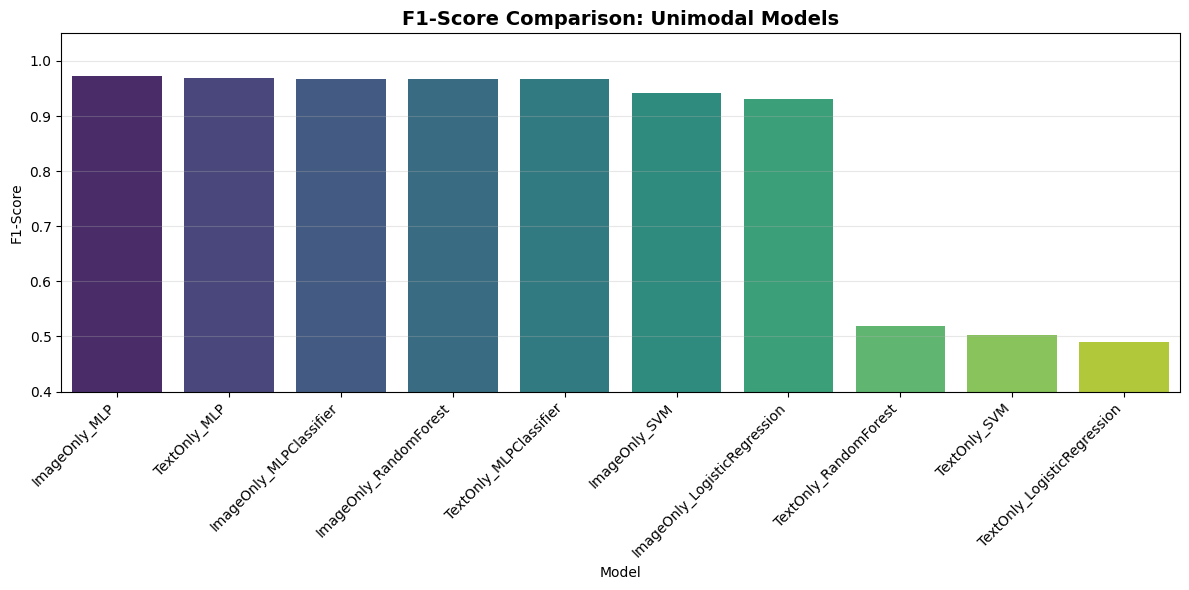

In [24]:
# Bar chart comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1-Score', data=df_summary, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('F1-Score Comparison: Unimodal Models', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0.4, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../reports/unimodal/figures/f1_comparison.png', dpi=300)
plt.show()

### 6. Failure Profile Generation

Identify cases where both text-only and image-only models are highly confident but incorrect. These represent cases where unimodal contexts fail and cross-modal correlation is required.

In [25]:
text_model.eval()
image_model.eval()
text_results = text_trainer.evaluate(text_test_loader)
image_results = image_trainer.evaluate(image_test_loader)
indices = np.arange(len(labels))
_, test_idx = train_test_split(indices, test_size=pipeline.test_size, random_state=pipeline.random_state, stratify=labels.numpy())

df_test = df.iloc[test_idx].copy().reset_index(drop=True)
df_test['text_pred'] = text_results['predictions']
df_test['text_prob'] = text_results['probabilities']
df_test['image_pred'] = image_results['predictions']
df_test['image_prob'] = image_results['probabilities']

df_test['text_wrong_confidence'] = np.where(df_test['target'] == 1, 1 - df_test['text_prob'], df_test['text_prob'])
df_test['image_wrong_confidence'] = np.where(df_test['target'] == 1, 1 - df_test['image_prob'], df_test['image_prob'])

df_incorrect_both = df_test[(df_test['text_pred'] != df_test['target']) & (df_test['image_pred'] != df_test['target'])].copy()
df_incorrect_both['combined_wrong_confidence'] = df_incorrect_both['text_wrong_confidence'] * df_incorrect_both['image_wrong_confidence']
df_failure_profile = df_incorrect_both.sort_values(by='combined_wrong_confidence', ascending=False)

failure_profile_path = '../../reports/unimodal/metrics/unimodal_failure_profile.csv'
df_failure_profile.to_csv(failure_profile_path, index=False)
print(f"✅ Failure profile exported with {len(df_failure_profile)} rows to {failure_profile_path}")

cols_to_print = ['multilingual_claim', 'claim', 'target', 'text_pred', 'text_prob', 'image_pred', 'image_prob', 'combined_wrong_confidence']
cols_avail = [c for c in cols_to_print if c in df_failure_profile.columns]
df_failure_profile[cols_avail].head(5)

✅ Failure profile exported with 31 rows to ../../reports/unimodal/metrics/unimodal_failure_profile.csv


,multilingual_claim,claim,target,text_pred,text_prob,image_pred,image_prob,combined_wrong_confidence
279,Libya’yı vuran kasırganın öncesini ve sonrasın...,Before and after satellite images of the hurri...,0,1,0.591485,1,1.000000,0.591485
529,Recente oorlogsgeweld in Charkov.,Recent war violence in Kharkiv.,0,1,0.591097,1,0.999993,0.591093
431,not enough information,Russian President Vladimir Putin with U.S. For...,0,1,0.589843,1,1.000000,0.589843
563,not enough information,Evangelical Liberty University president Jerry...,0,1,0.589843,1,0.999999,0.589843
306,not enough information,Images of Taco Bell items were from a lawsuit ...,0,1,0.589843,1,0.999999,0.589842
